In [10]:
import sys
!"{sys.executable}" -m pip install pandas matplotlib seaborn

# PHẦN I: KẾT NỐI DỮ LIỆU VỚI SERVER HADOOP

In [11]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen

# Thêm đường dẫn src để import file cấu hình settings.py
sys.path.append('../src')
from config.settings import HDFS_URL

# Trích xuất IP tĩnh của máy chủ từ HDFS_URL (Tailscale IP)
host_ip = HDFS_URL.split('://')[1].split(':')[0]
url = f"http://{host_ip}:9870/webhdfs/v1/student_data.csv?op=OPEN"

try:
    with urlopen(url) as response:
        df = pd.read_csv(response)
    print("Tải thành công dữ liệu từ HDFS (qua Tailscale)")
    print(f"Tổng số dòng dữ liệu: {len(df)}")
    
    # Hiển thị 5 dòng đầu để kiểm tra
    display(df.head())
except Exception as e:
    print(" Lỗi kết nối đến HDFS:", e)


Tải thành công dữ liệu từ HDFS (qua Tailscale)
Tổng số dòng dữ liệu: 200000


,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass


##  2. KÍCH THƯỚC VÀ ĐÁNH GIÁ SƠ BỘ BỘ DỮ LIỆU (DATA SCALE EVALUATION)

In [12]:
print("=== THÔNG TIN CHUNG VỀ BỘ DỮ LIỆU ===")
df.info()

=== THÔNG TIN CHUNG VỀ BỘ DỮ LIỆU ===
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   gender                    200000 non-null  str    
 1   age                       200000 non-null  int64  
 2   parental_education_level  200000 non-null  int64  
 3   family_income             195975 non-null  float64
 4   daily_study_hours         200000 non-null  float64
 5   attendance_rate           200000 non-null  float64
 6   sleep_hours               195887 non-null  float64
 7   stress_level              196087 non-null  float64
 8   motivation_score          200000 non-null  int64  
 9   private_tutoring          200000 non-null  bool   
 10  internet_quality          200000 non-null  int64  
 11  math_score                200000 non-null  int64  
 12  reading_score             200000 non-null  int64  
 13  writing_score    

In [13]:
print("\n=== KÍCH THƯỚC BỘ DỮ LIỆU ===")
print(f"Số lượng sinh viên (Dòng): {df.shape[0]}")
print(f"Số lượng thuộc tính (Cột): {df.shape[1]}")


=== KÍCH THƯỚC BỘ DỮ LIỆU ===
Số lượng sinh viên (Dòng): 200000
Số lượng thuộc tính (Cột): 15


# Phần II: EDA (Explore Data Analyst) 

## 🧼 PHẦN 1: TIỀN XỬ LÝ VÀ LÀM SẠCH DỮ LIỆU (DATA CLEANING)

Sau khi kiểm tra tổng quan cấu trúc, bước tiếp theo là thực hiện làm sạch dữ liệu. Đây là giai đoạn tối quan trọng nhằm loại bỏ các yếu tố "nhiễu" (noise), dữ liệu rác hoặc sai sót trong quá trình thu thập hệ thống từ Hadoop HDFS. Đối với tập dữ liệu gồm 200,000 dòng này, quy trình tiền xử lý tập trung vào hai bài toán cốt lõi đầu tiên:


### 1. Loại bỏ dữ liệu trùng lặp (Handling Duplicates)
* **Mục tiêu:** Nhận diện và xóa bỏ các dòng dữ liệu bị lặp lại hoàn toàn do lỗi ghi nhận ngẫu nhiên của hệ thống, chỉ giữ lại bản ghi đầu tiên (`keep='first'`).
* **Ý nghĩa:** Tránh hiện tượng phóng đại sai lệch (overrepresentation) số lượng mẫu, bảo toàn tính khách quan cho các phép tính xác suất Đậu/Rớt sau này.

In [14]:
Duplicate_value = df.duplicated().sum()
print(f"Phat hien {Duplicate_value} dong trung lap.")

Phat hien 0 dong trung lap.


### 2. Xử lý dữ liệu ngoại lại (Outliers)
* **Nhiễu dữ liệu và Giá trị dị biệt (Outliers):** Do quy mô dữ liệu lên tới 200,000 dòng được tổng hợp từ nhiều nguồn khảo sát nhập tay khác nhau, hệ thống chắc chắn sẽ dính phải các giá trị dị biệt vật lý do lỗi gõ phím (Typo) hoặc lỗi hệ thống. Cụ thể nhóm nghiên cứu cần cô lập và xử lý các Outliers mang tính phi logic như:
    * *Tỷ lệ chuyên cần (`attendance_rate`):* Xuất hiện các giá trị âm ( < 0) hoặc vượt quá 100% ( > 1.0).
    * *Thời gian sinh hoạt (`daily_study_hours`, `sleep_hours`):* Các con số vô lý vượt quá quỹ thời gian 24 giờ/ngày hoặc số giờ ngủ âm.
    * *Điểm số các môn (`math_score`, `reading_score`, `writing_score`):* Điểm số nằm ngoài thang đo quy chuẩn quy định (ví dụ: điểm âm hoặc vượt quá mức điểm tối đa của bài thi).

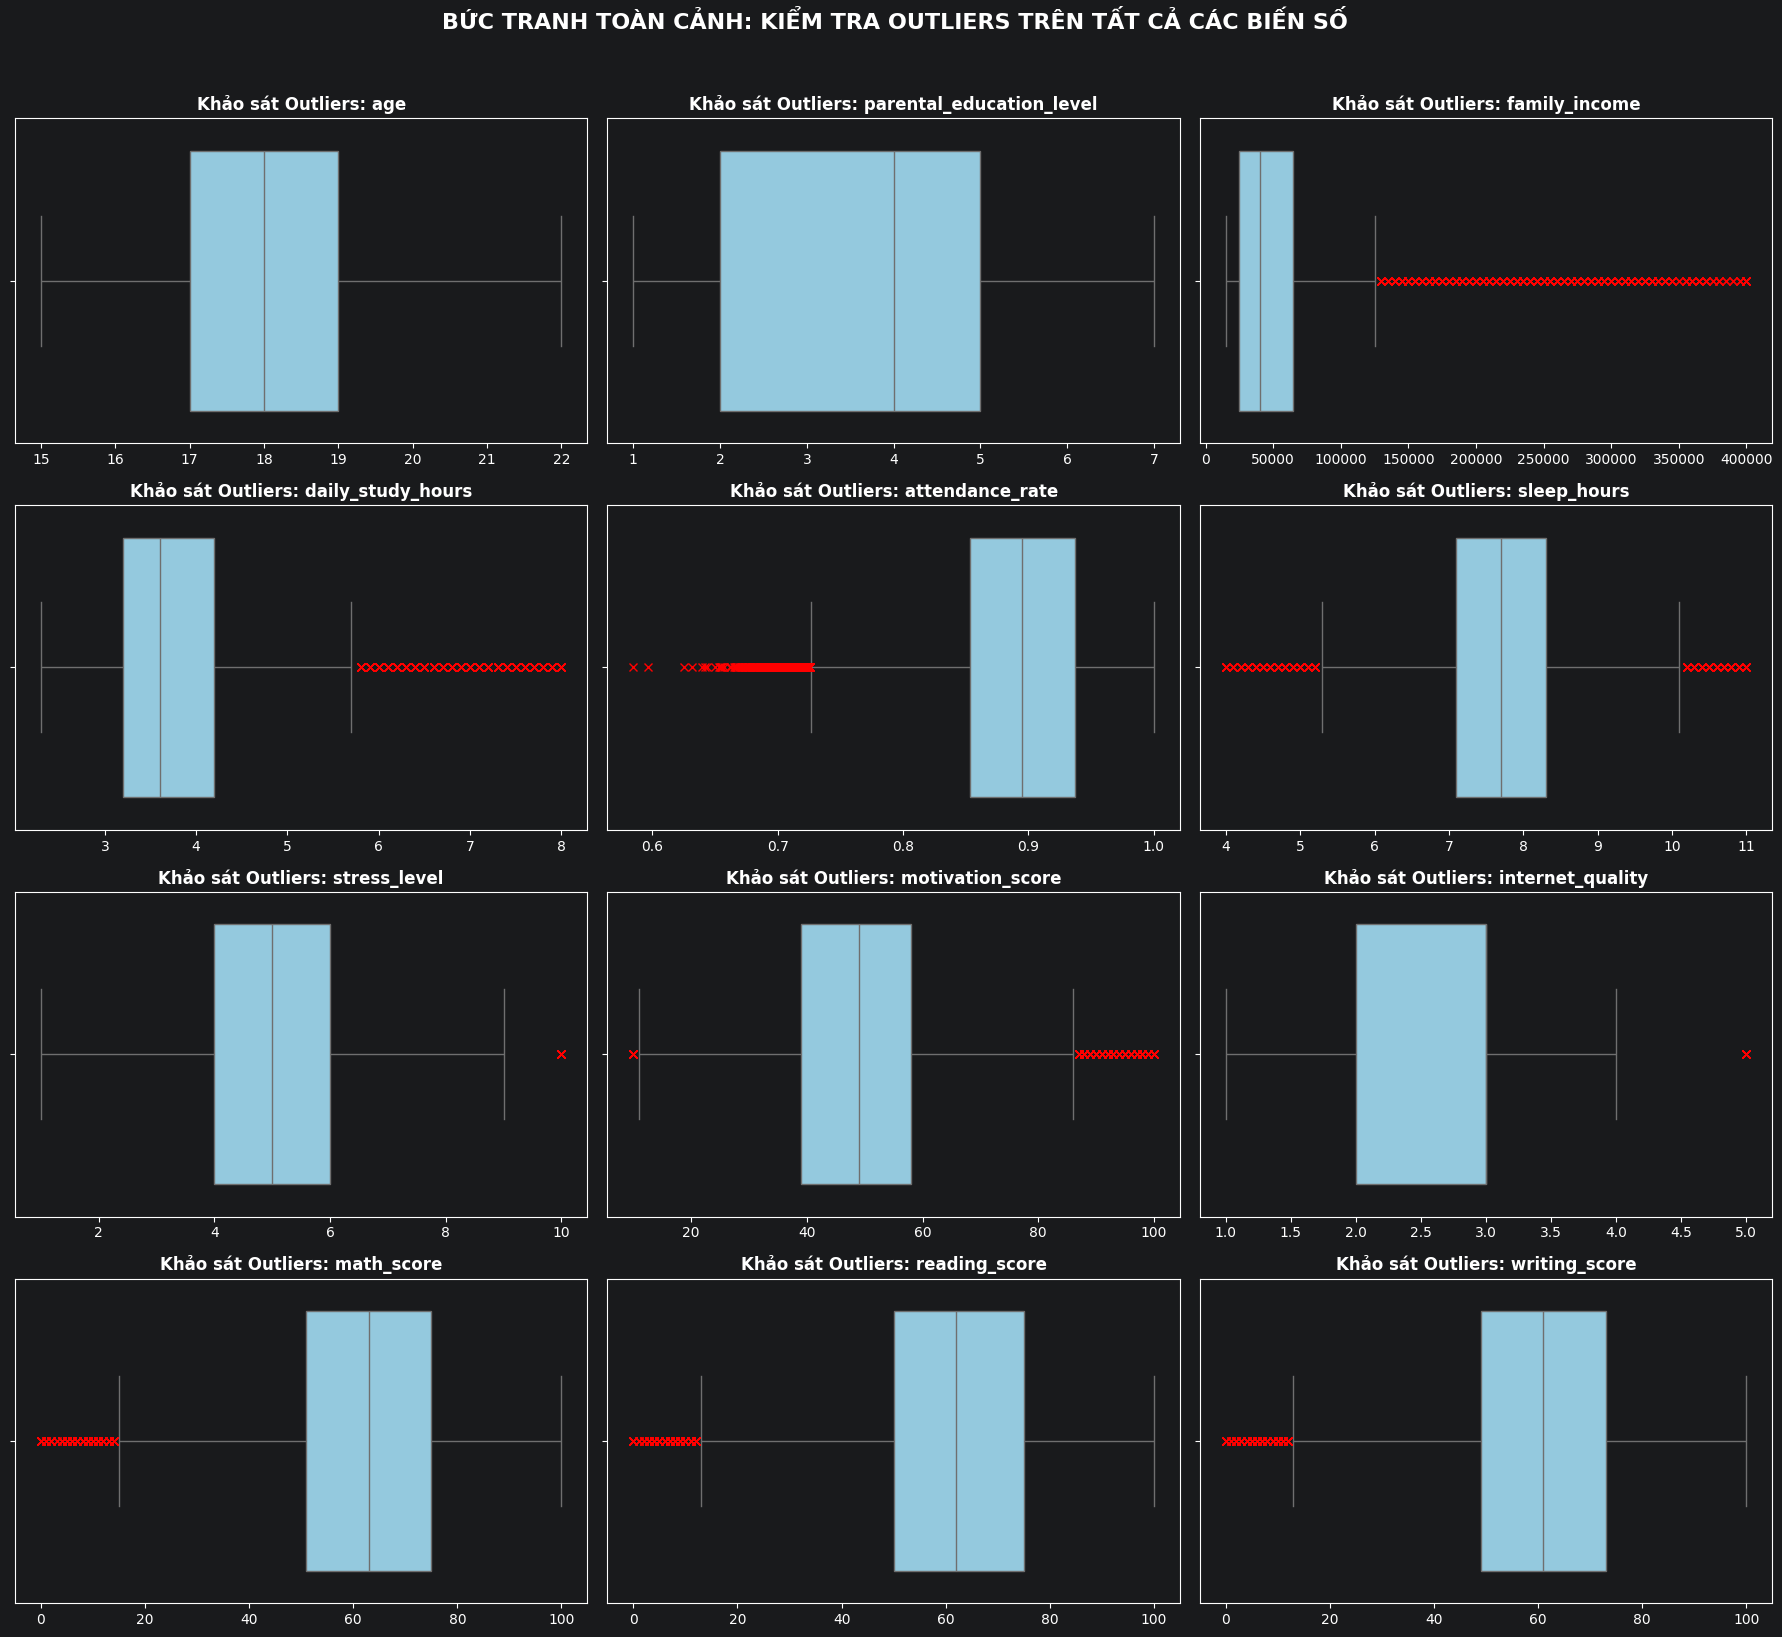

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tự động lấy danh sách tất cả các cột có kiểu dữ liệu là số
cac_cot_so = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = len(cac_cot_so)

# 2. Tính toán số lượng hàng cần vẽ (Mỗi hàng ta xếp 3 biểu đồ cho gọn và đẹp)
cols_per_row = 3
num_rows = (num_cols + cols_per_row - 1) // cols_per_row

# 3. Khởi tạo khung tranh tổng thể
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
fig.suptitle('BỨC TRANH TOÀN CẢNH: KIỂM TRA OUTLIERS TRÊN TẤT CẢ CÁC BIẾN SỐ', fontsize=16, fontweight='bold', y=1.02)

# Phẳng hóa mảng axes để dùng vòng lặp cho dễ
axes = axes.flatten()

# 4. Vòng lặp tự động vẽ Boxplot cho từng cột số
for i, col in enumerate(cac_cot_so):
    sns.boxplot(ax=axes[i], x=df[col], color='skyblue', flierprops={"marker": "x", "markeredgecolor": "red"})
    axes[i].set_title(f'Khảo sát Outliers: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

# 5. Ẩn đi các ô biểu đồ thừa nếu số lượng cột không chia hết cho 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Phân tích Outliers thực tế và Định hướng bảo tồn dữ liệu (Outlier Retention Strategy)

Dựa trên bức tranh đồ thị ma trận Boxplot vừa xuất ra, nhóm nghiên cứu ghi nhận các đặc trưng dị biệt hệ thống. Tuy nhiên, thay vì áp dụng phương pháp loại bỏ (Xóa dòng), nhóm quyết định **giữ lại toàn bộ các giá trị Outliers này**. Lý do chuyên môn và bản chất hệ thống của từng nhóm biến số được luận cứ cụ thể như sau:

* **Nhóm biến Điểm số học thuật (`math_score`, `reading_score`, `writing_score`):** Đồ thị ghi nhận dải Outliers đỏ tập trung ở vùng biên trái (các mức điểm cực thấp dưới 15-20 điểm). Trong thực tế học đường, đây là nhóm học viên bị "liệt" môn hoặc gặp khủng hoảng nghiêm trọng trong kỳ thi. Việc giữ lại nhóm này là tối quan trọng để mô hình sau này có thể nhận diện và dự đoán chính xác các đối tượng có nguy cơ Rớt (`Fail`) cao nhằm đưa ra giải pháp can thiệp sớm.
* **Nhóm biến Gia cảnh và Kinh tế (`family_income`):** Biểu đồ xuất hiện dải Outliers kéo dài bất bình thường về phía bên phải (vọt lên mức 400,000). Đây là phân phối lệch phải (`Right-skewed`) phản ánh hoàn toàn đúng thực tế xã hội về khoảng cách giàu nghèo (một số lượng nhỏ hộ gia đình có thu nhập đột biến). Nhóm quyết định giữ lại phân khúc này để phục vụ cho bài toán phân tích sâu về mối liên hệ giữa điều kiện kinh tế cực thịnh và kết quả học tập của con em họ.
* **Nhóm biến Sinh hoạt và Hành vi (`daily_study_hours`, `attendance_rate`, `sleep_hours`):** Ghi nhận các hành vi sinh hoạt cực đoan (tự học đột biến lên đến 8 giờ/ngày, cúp học sâu dưới 60%, hoặc rối loạn giấc ngủ ngủ quá ít/quá nhiều). Đây là các biến động lực mang tính cá biệt nhưng có thật. Giữ lại các mẫu này giúp mô hình Machine Learning giữ được cái nhìn đa chiều về tính đa dạng trong lối sống của học viên.
* **Nhóm biến mức độ căng thẳng, động lực học tập và chất lượng Internet (`stress_level`, `motivation_score`, `internet_quality`):** Biểu đồ Boxplot ghi nhận một số giá trị nằm ngoài khoảng phân bố chính của dữ liệu. Đối với motivation_score, các điểm số rất cao hoặc rất thấp phản ánh sự khác biệt rõ rệt về động lực học tập giữa các học sinh và hoàn toàn có thể xuất hiện trong thực tế. Tương tự, stress_level và internet_quality chỉ xuất hiện một số ít giá trị ngoại lai ở ngưỡng trên, cho thấy tồn tại những học sinh có mức độ căng thẳng hoặc điều kiện kết nối Internet vượt trội so với mặt bằng chung. Các trường hợp này không mang tính bất hợp lý mà có thể cung cấp thông tin quan trọng cho việc phân tích ảnh hưởng của yếu tố tâm lý và điều kiện học tập đến kết quả học tập, do đó được giữ nguyên trong bộ dữ liệu.

**💡 Giải pháp kỹ thuật đồng bộ:** Để các Outliers thực tế này không làm ảnh hưởng và kéo lệch các phép tính thống kê ở bước sau, nhóm nghiên cứu thay thế hoàn toàn toán học Trung bình (`Mean`) bằng toán học **Trung vị (`Median`)** trên toàn bộ tiến trình xử lý khuyết thiếu (`Group Imputation`). Số trung vị mang đặc tính trơ (`Robust`) trước Outliers, đảm bảo giữ được 100% dung lượng mẫu (200,000 dòng) mà phép toán bổ khuyết vẫn đạt độ khách quan tuyệt đối.


### 3. Phương pháp tiếp cận xử lý dữ liệu khuyết thiếu (Missing Data Imputation Strategy)

Trong quản trị và phân tích dữ liệu giáo dục, việc xử lý các giá trị khuyết thiếu (Null/NaN) là một bước bắt buộc để đảm bảo tính liên tục của các thuật toán toán học. Thay vì áp dụng phương pháp rải đều một con số trung bình tổng (`Naive Imputation`) cho toàn bộ bảng dữ liệu — một kỹ thuật sơ cấp dễ làm phẳng dữ liệu và triệt tiêu tính phân hóa đặc trưng — nghiên cứu này sử dụng phương pháp **Bổ khuyết theo phân khúc ngữ cảnh (Context-Aware Group Imputation)** thông qua việc kết hợp hai hàm `.groupby()` và `.transform()` trong thư viện Pandas.

**Nguyên lý vận hành:** Hệ thống sẽ nhóm các đối tượng học viên có cùng đặc trưng nền tảng lại với nhau, sau đó tính toán giá trị đại diện (Trung bình `Mean` hoặc Trung vị `Median`) của riêng phân khúc đó để bù đắp vào các ô trống. Phương pháp này giúp bảo toàn cấu trúc phân phối tự nhiên của 200,000 dòng dữ liệu mà không gây ra hiện tượng nhiễu hệ thống.

In [16]:
print("\n=== KIỂM TRA DỮ LIỆU BỊ KHUYẾT THIẾU ===")
print(df.isnull().sum())


=== KIỂM TRA DỮ LIỆU BỊ KHUYẾT THIẾU ===
gender                         0
age                            0
parental_education_level       0
family_income               4025
daily_study_hours              0
attendance_rate                0
sleep_hours                 4113
stress_level                3913
motivation_score               0
private_tutoring               0
internet_quality               0
math_score                     0
reading_score                  0
writing_score                  0
pass_fail                      0
dtype: int64


### Biện pháp xử lý chi tiết và Lý do luận cứ cho từng biến khuyết thiếu

Đối với 3 trường dữ liệu dính lỗi khuyết thiếu được phát hiện trong tập dữ liệu 200,000 dòng, nhóm nghiên cứu không cô lập các biến này mà đặt chúng vào các mối quan hệ tương quan đặc trưng của hệ sinh thái giáo dục để xử lý:

#### A. Biến Thu nhập gia đình (`family_income`) - Thiếu 4,025 dòng
* **Cách xử lý:** Sử dụng giá trị **Trung vị (Median)** của biến `family_income` sau khi gom nhóm theo Trình độ học vấn của phụ huynh (`parental_education_level`).
* **Lý do luận cứ:** * Trong kinh tế học vĩ mô và xã hội học, trình độ học vấn của cha mẹ (nền tảng tri thức) luôn có mối liên hệ hữu cơ, tỷ lệ thuận với khả năng tạo ra thu nhập trong xã hội. Do đó, những phụ huynh có cùng mức học vấn thường sẽ có mức thu nhập nằm trong một phân khúc nhất định.
    * Lý do chọn **Trung vị (Median)** thay vì Trung bình (Mean): Dữ liệu thu nhập là dạng dữ liệu cực kỳ nhạy cảm và dễ bị lệch do các giá trị cực đoan (Outliers - ví dụ một vài hộ gia đình có thu nhập siêu cao sẽ kéo mác trung bình của cả nhóm lên rất vô lý). Số trung vị sẽ phản ánh chính xác nhất mức thu nhập của một hộ gia đình "tầm trung" trong phân khúc học vấn đó mà không bị nhiễu.

#### B. Biến Số giờ ngủ mỗi đêm (`sleep_hours`) - Thiếu 4,113 dòng
* **Cách xử lý:** Sử dụng giá trị **Trung bình (Mean)** của biến `sleep_hours` sau khi gom nhóm theo trạng thái Đậu/Rớt (`pass_fail`).
* **Lý do luận cứ:** * Thời lượng ngủ phản ánh trực tiếp thói quen sinh hoạt và mức độ cân bằng cuộc sống của người học. Nhóm học viên thi Rớt (`Fail`) thường có xu hướng phân bổ thời gian không hợp lý (hoặc ngủ quá ít do thức đêm cày game, lo âu, hoặc ngủ quá nhiều dẫn đến lười biếng). Ngược lại, nhóm học viên thi Đậu (`Pass`) thường có khung giờ sinh hoạt điều độ hơn.
    * Việc tính toán thời lượng ngủ trung bình riêng biệt cho hai nhóm này giúp bảo toàn tính phân hóa đặc trưng về mặt hành vi sinh hoạt của học viên dựa trên kết quả đầu ra của họ.

#### C. Biến Mức độ áp lực (`stress_level`) - Thiếu 3,913 dòng
* **Cách xử lý:** Sử dụng giá trị **Trung bình (Mean)** của biến `stress_level` sau khi gom nhóm theo kết quả Đậu/Rớt (`pass_fail`).
* **Lý do luận cứ:** * *Đặc trưng hình thái dữ liệu:* Kết quả trực quan hóa từ ma trận Boxplot cho thấy biến `stress_level` có phân phối tương đối ổn định, không xuất hiện hiện tượng lệch pha cực đoan (`not heavily skewed`) hay dính dải Outliers dày đặc như trường thu nhập. Do đó, việc sử dụng toán học Trung bình (`Mean`) cho biến này là hoàn toàn an toàn, phản ánh chính xác kỳ vọng toán học và tâm điểm phân phối của từng nhóm học viên.
    * *Bản chất hệ sinh thái giáo dục:* Áp lực tâm lý (Stress) là một biến động lực học có mối quan hệ nhân quả rất mạnh với kết quả học tập. Nhóm học viên chịu áp lực quá tải hoặc mất phương hướng thường có tỷ lệ thi rớt cao vượt trội. 
    * Nếu chúng ta áp dụng phương pháp rải đều mức stress trung bình tổng của cả trường cho các ô trống, chúng ta sẽ vô tình làm "giảm" mức stress thực tế của những bạn đang gặp khủng hoảng (nhóm `Fail`) và làm "tăng" mức stress của những bạn đang kiểm soát tốt lộ trình học (nhóm `Pass`). Do đó, phân tách và tính toán giá trị `Mean` riêng biệt theo bộ lọc `pass_fail` là giải pháp tối ưu để bảo toàn nguyên vẹn tính phân hóa dữ liệu thô.

In [17]:
# Tạo bản sao dữ liệu gốc để bổ khuyết dữ liệu
df_clean = df.copy()

print("=== BẮT ĐẦU QUY TRÌNH BỔ KHUYẾT DỮ LIỆU THEO NGỮ CẢNH CẢI TIẾN ===")

# 1. XỬ LÝ BIẾN A: family_income -> Dùng MEDIAN nhóm theo parental_education_level
if 'family_income' in df_clean.columns and 'parental_education_level' in df_clean.columns:
    df_clean['family_income'] = df_clean['family_income'].fillna(
        df_clean.groupby('parental_education_level')['family_income'].transform('median')
    )
    print("Family_income bằng TRUNG VỊ (Median) theo nhóm học vấn phụ huynh.")

# 2. XỬ LÝ BIẾN B: sleep_hours -> Dùng MEAN nhóm theo pass_fail
if 'sleep_hours' in df_clean.columns and 'pass_fail' in df_clean.columns:
    df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(
        df_clean.groupby('pass_fail')['sleep_hours'].transform('mean')
    )
    print("Sleep_hours bằng TRUNG BÌNH (Mean) theo nhóm Pass/Fail.")

# 3. XỬ LÝ BIẾN C: stress_level -> Dùng MEAN nhóm theo pass_fail
if 'stress_level' in df_clean.columns and 'pass_fail' in df_clean.columns:
    df_clean['stress_level'] = df_clean['stress_level'].fillna(
        df_clean.groupby('pass_fail')['stress_level'].transform('mean')
    )
    print("Stress_level bằng TRUNG BÌNH (Mean) theo nhóm Pass/Fail.")

print("\n--- KIỂM TRA TỔNG THỂ KẾT QUẢ SAU NGHIỆM THU ---")
print(f"Tổng số mẫu được bảo toàn nguyên vẹn: {df_clean.shape[0]} dòng.")
print("Số lượng ô khuyết thiếu (Null) còn lại ở mỗi cột:")
print(df_clean[['family_income', 'sleep_hours', 'stress_level']].isnull().sum())

=== BẮT ĐẦU QUY TRÌNH BỔ KHUYẾT DỮ LIỆU THEO NGỮ CẢNH CẢI TIẾN ===
Family_income bằng TRUNG VỊ (Median) theo nhóm học vấn phụ huynh.
Sleep_hours bằng TRUNG BÌNH (Mean) theo nhóm Pass/Fail.
Stress_level bằng TRUNG BÌNH (Mean) theo nhóm Pass/Fail.

--- KIỂM TRA TỔNG THỂ KẾT QUẢ SAU NGHIỆM THU ---
Tổng số mẫu được bảo toàn nguyên vẹn: 200000 dòng.
Số lượng ô khuyết thiếu (Null) còn lại ở mỗi cột:
family_income    0
sleep_hours      0
stress_level     0
dtype: int64


## 📊 PHẦN 2: PHÂN TÍCH THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)

Sau khi hoàn tất quy trình làm sạch, bảo toàn nguyên vẹn 200,000 dòng dữ liệu và xử lý khuyết thiếu bằng phương pháp thống kê mạnh (`Robust Imputation`), nhóm nghiên cứu tiến hành bước **Phân tích Thống kê Mô tả**. Đây là giai đoạn nền tảng mang tính bắt buộc trong tiến trình EDA (Exploratory Data Analysis) nhằm "đọc vị" và định lượng bức tranh toàn cảnh của tập dữ liệu trước khi đưa vào các mô hình học máy phức tạp.

**Mục tiêu cốt lõi của bước này bao gồm:**
1. **Định hình phân phối:** Xác định xu hướng trung tâm (Trọng tâm dữ liệu nằm ở đâu?) và mức độ phân tán (Dữ liệu biến động đồng đều hay phân hóa mạnh?).
2. **Nhận diện đặc trưng học đường:** Khảo sát tần suất, tỷ lệ phần trăm của các yếu tố gia cảnh (thu nhập, học vấn phụ huynh) và thói quen sinh hoạt (giờ học, giờ ngủ, tỷ lệ chuyên cần) tác động thế nào đến tổng thể.
3. **Phát hiện nghịch lý dữ liệu (nếu có):** Đối chiếu giữa các giá trị toán học để tìm ra các điểm bất thường hoặc các manh mối tương quan ban đầu.

### Thiết kế cấu trúc các mục khảo sát Thống kê mô tả

Để khai thác triệt để thông tin từ 15 thuộc tính, nghiên cứu phân tách hệ thống thành 3 trục mục tiêu rõ rệt. Mỗi trục sẽ đi kèm một bộ công cụ toán học và chỉ số đo lường chuyên biệt:

### 1. Trục Biến số (Numerical Features)
* **Đối tượng khảo sát:** `age`, `family_income`, `daily_study_hours`, `attendance_rate`, `sleep_hours`, `stress_level`, `motivation_score`, `math_score`, `reading_score`, `writing_score`.
* **Các chỉ số đo lường:** * *Xu hướng trung tâm:* Mean (Trung bình), Median (Trung vị - 50%).
    * *Độ phân tán:* Std (Độ lệch chuẩn), Min, Max, Khoảng phân vị (25%, 75%).
* **Mục tiêu phân tích:** Đo lường xem một sinh viên " trung bình " trong tập dữ liệu đang học bao nhiêu tiếng, ngủ bao nhiêu giờ, đạt mức điểm trung bình bao nhiêu và khoảng cách chênh lệch giữa các nhóm học sinh với nhau.

### 2. Trục Biến định tính và Nhãn phân loại (Categorical & Boolean Features)
* **Đối tượng khảo sát:** `gender`, `parental_education_level`, `private_tutoring`, `internet_quality`, `pass_fail`.
* **Các chỉ số đo lường:** Unique (Số nhóm phân loại), Top (Mức độ phổ biến nhất), Freq (Tần suất xuất hiện của nhóm phổ biến nhất) và Tỷ lệ % cấu thành.
* **Mục tiêu phân tích:** Định lượng cơ cấu sinh viên theo giới tính, chất lượng internet của đa số sinh viên ở mức nào, và tỷ lệ phân bổ thực tế của biến mục tiêu `pass_fail` (Tỷ lệ Đậu/Rớt đang cân bằng hay bị lệch).

In [18]:
import pandas as pd
# Cấu hình hiển thị số thực dạng thập phân cho dễ đọc, né định dạng e+05 khó nhìn
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("==================================1. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) =========")
thong_ke_so = df_clean.describe()
display(thong_ke_so)

print("\n=============================== 2. THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH TÍNH (CATEGORICAL) =========")
thong_ke_chu = df_clean.describe(include=['str', 'bool'])
display(thong_ke_chu)

==================================1. THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ (NUMERICAL) =========


,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,internet_quality,math_score,reading_score,writing_score
count,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,18.15,3.69,51328.30,3.75,0.89,7.71,5.10,48.58,2.91,62.97,62.51,61.00
std,1.65,1.61,35824.34,0.83,0.06,0.92,1.44,13.64,0.72,17.07,18.04,17.14
min,15.00,1.00,15000.00,2.30,0.58,4.00,1.00,10.00,1.00,0.00,0.00,0.00
25%,17.00,2.00,25000.00,3.20,0.85,7.10,4.00,39.00,2.00,51.00,50.00,49.00
50%,18.00,4.00,40000.00,3.60,0.90,7.70,5.00,49.00,3.00,63.00,62.00,61.00
75%,19.00,5.00,65000.00,4.20,0.94,8.30,6.00,58.00,3.00,75.00,75.00,73.00
max,22.00,7.00,400000.00,8.00,1.00,11.00,10.00,100.00,5.00,100.00,100.00,100.00



=============================== 2. THỐNG KÊ MÔ TẢ CÁC BIẾN ĐỊNH TÍNH (CATEGORICAL) =========


,gender,private_tutoring,pass_fail
count,200000,200000,200000
unique,2,2,2
top,Female,False,Pass
freq,104075,145236,109389


--- BẢNG SỐ LIỆU THỐNG KÊ MÔ TẢ ĐIỂM SỐ 3 MÔN ---


,math_score,reading_score,writing_score
count,200000.00,200000.00,200000.00
mean,62.97,62.51,61.00
std,17.07,18.04,17.14
min,0.00,0.00,0.00
25%,51.00,50.00,49.00
50%,63.00,62.00,61.00
75%,75.00,75.00,73.00
max,100.00,100.00,100.00


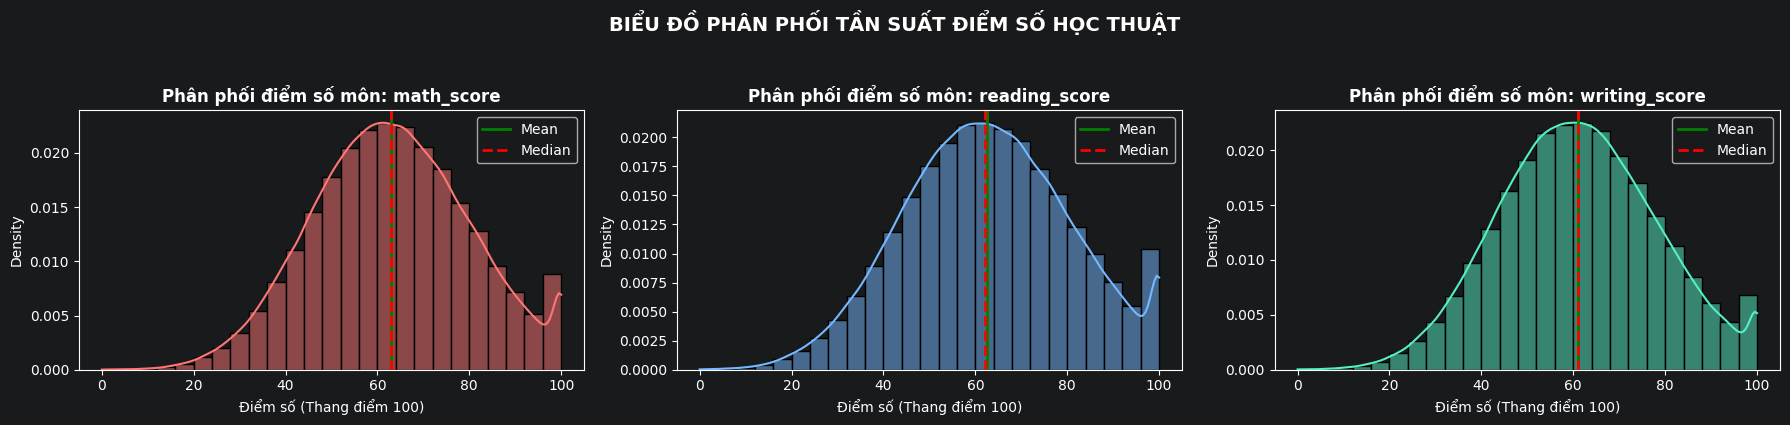

In [19]:
print("--- BẢNG SỐ LIỆU THỐNG KÊ MÔ TẢ ĐIỂM SỐ 3 MÔN ---")
display(df_clean[['math_score', 'reading_score', 'writing_score']].describe())

# Vẽ biểu đồ phân phối tần suất song song
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('BIỂU ĐỒ PHÂN PHỐI TẦN SUẤT ĐIỂM SỐ HỌC THUẬT', fontsize=14, fontweight='bold', y=1.05)

cac_mon = ['math_score', 'reading_score', 'writing_score']
mau_mon = ['#ff7675', '#74b9ff', '#55efc4']

for i, col in enumerate(cac_mon):
    sns.histplot(ax=axes[i], x=df_clean[col], kde=True, color=mau_mon[i], stat="density", bins=25)
    axes[i].axvline(df_clean[col].mean(), color='green', linestyle='-', linewidth=2, label=f'Mean')
    axes[i].axvline(df_clean[col].median(), color='red', linestyle='--', linewidth=2, label=f'Median')
    axes[i].set_title(f'Phân phối điểm số môn: {col}', fontweight='bold')
    axes[i].set_xlabel('Điểm số (Thang điểm 100)')
    axes[i].legend()

plt.tight_layout()
plt.show()

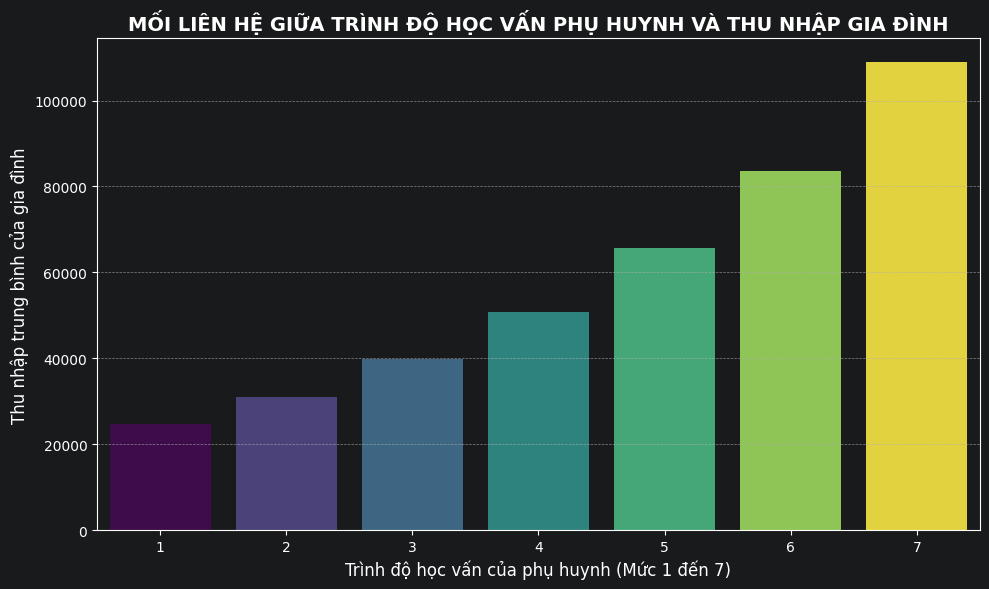

In [27]:
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột
sns.barplot(
    x='parental_education_level',
    y='family_income',
    data=df_clean,
    palette='viridis',
    hue='parental_education_level', # Gắn hue bằng đúng trục x để hết bị cảnh báo
    legend=False,                   # Tắt cái bảng chú thích (vì không cần thiết)
    errorbar=None
)

# Thêm tiêu đề và nhãn
plt.title('MỐI LIÊN HỆ GIỮA TRÌNH ĐỘ HỌC VẤN PHỤ HUYNH VÀ THU NHẬP GIA ĐÌNH', fontsize=14, fontweight='bold')
plt.xlabel('Trình độ học vấn của phụ huynh (Mức 1 đến 7)', fontsize=12)
plt.ylabel('Thu nhập trung bình của gia đình', fontsize=12)

# Thêm lưới đứt nét ngang cho dễ nhìn mốc tiền
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

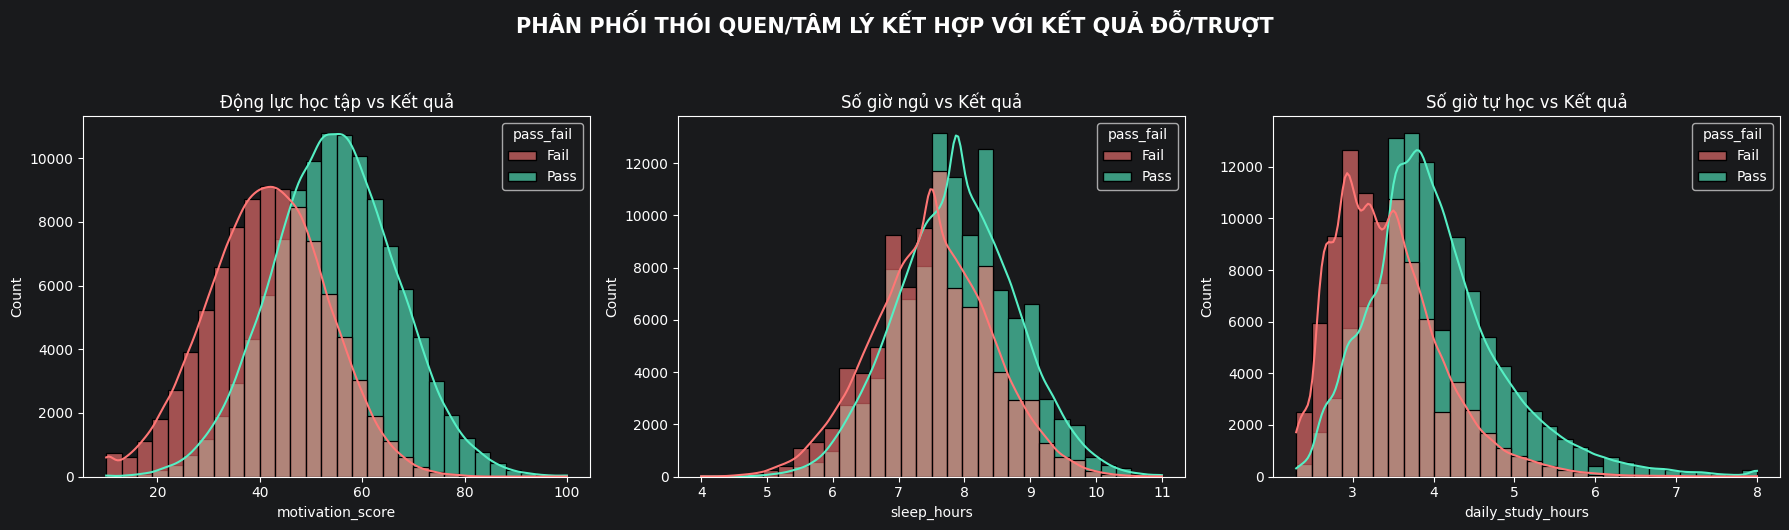

In [28]:
# Tạo khung gồm 3 biểu đồ con (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle('PHÂN PHỐI THÓI QUEN/TÂM LÝ KẾT HỢP VỚI KẾT QUẢ ĐỖ/TRƯỢT', fontsize=15, fontweight='bold', y=1.05)
# Định nghĩa bảng màu rõ ràng cho Pass (Xanh) và Fail (Đỏ)
palette_dict = {'Pass': '#55efc4', 'Fail': '#ff7675'}
# 1. Động lực học tập (motivation_score) phân rã theo pass_fail
sns.histplot(x='motivation_score', hue='pass_fail', data=df_clean, kde=True, ax=axes[0], palette=palette_dict, bins=30, alpha=0.6)
axes[0].set_title('Động lực học tập vs Kết quả', fontsize=12)
# 2. Số giờ ngủ (sleep_hours) phân rã theo pass_fail
sns.histplot(x='sleep_hours', hue='pass_fail', data=df_clean, kde=True, ax=axes[1], palette=palette_dict, bins=30, alpha=0.6)
axes[1].set_title('Số giờ ngủ vs Kết quả', fontsize=12)
# 3. Số giờ học mỗi ngày (daily_study_hours) phân rã theo pass_fail
sns.histplot(x='daily_study_hours', hue='pass_fail', data=df_clean, kde=True, ax=axes[2], palette=palette_dict, bins=30, alpha=0.6)
axes[2].set_title('Số giờ tự học vs Kết quả', fontsize=12)
# Tự động căn chỉnh khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

### 3. PHÂN TÍCH MA TRẬN TƯƠNG QUAN (CORRELATION ANALYSIS)

Sau khi hiểu rõ hình thái phân phối độc lập của từng thuộc tính, nhóm nghiên cứu tiến hành bước **Phân tích hệ số tương quan Pearson**. Mục tiêu của giai đoạn này là định lượng mối quan hệ tuyến tính giữa các cặp biến số, từ đó tìm ra các "mối ràng buộc" ngầm trong hành vi và kết quả học tập của sinh viên.

**Nguyên tắc đọc ma trận tương quan:**
* Hệ số tương quan chạy từ $[-1]$ đến $[1]$.
* Gần $1$: Tương quan thuận mạnh (Thằng này tăng, thằng kia tăng vọt).
* Gần $-1$: Tương quan nghịch mạnh (Thằng này tăng, thằng kia giảm sâu).
* Gần $0$: Không có mối quan hệ tuyến tính.
*Lưu ý kỹ thuật:* Để đánh giá trực tiếp mức độ ảnh hưởng của các yếu tố đến kết quả đầu ra, biến mục tiêu `pass_fail` tạm thời được mã hóa thành dạng số nhị phân ($Pass = 1$, $Fail = 0$) trước khi đưa vào ma trận tính toán.

========= 🌡️ ĐANG TÍNH TOÁN MA TRẬN TƯƠNG QUAN TỔNG LỰC =========


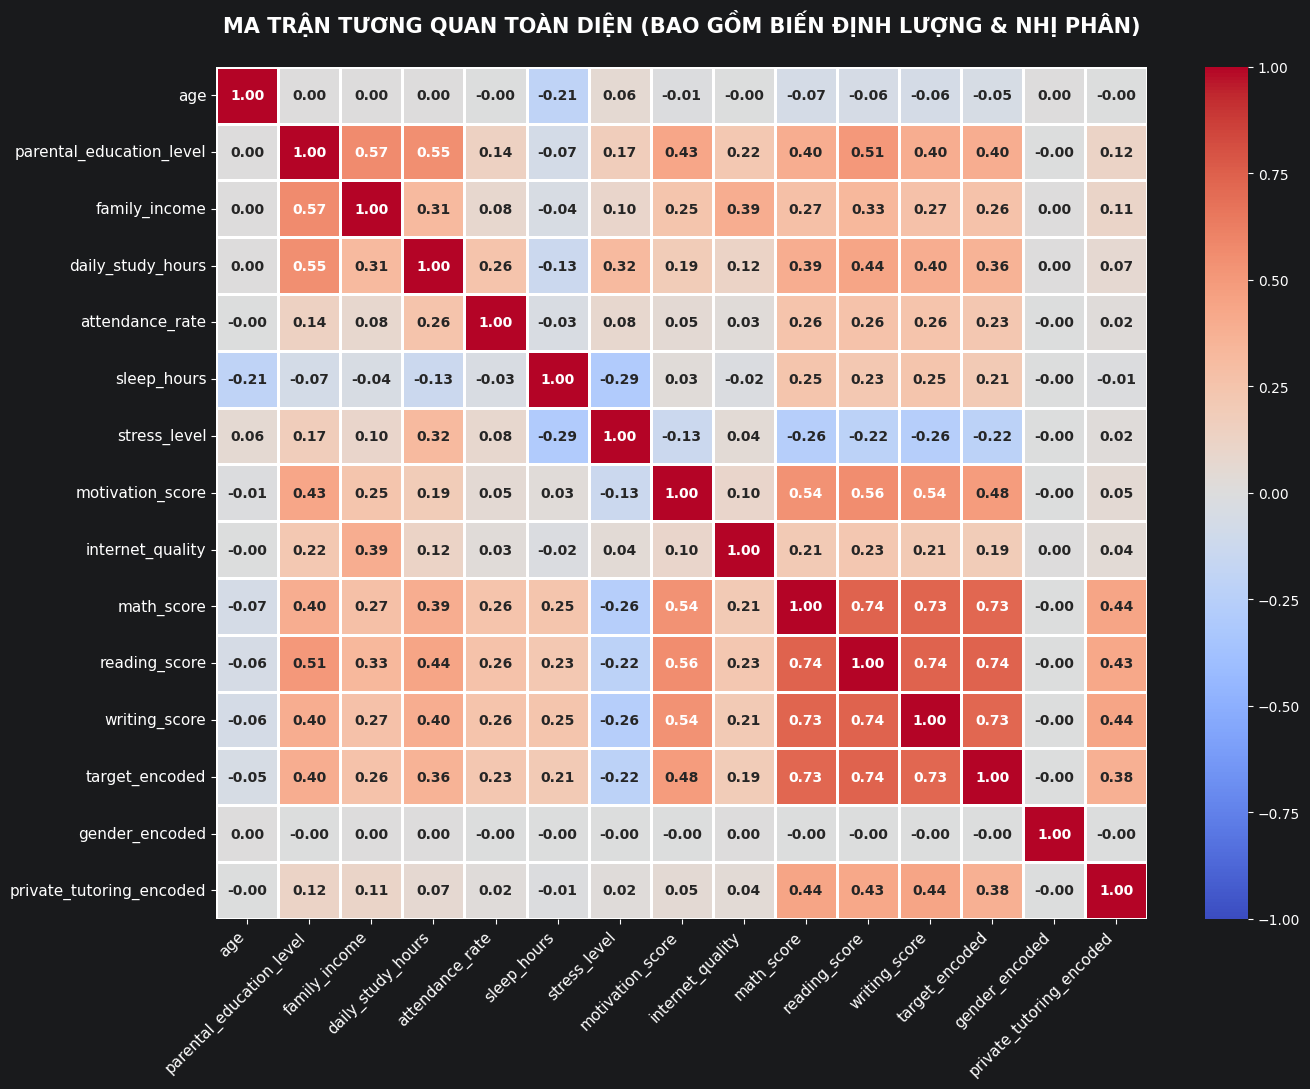

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("========= 🌡️ ĐANG TÍNH TOÁN MA TRẬN TƯƠNG QUAN TỔNG LỰC =========")

# 1. Tạo bản sao tạm thời để mã hóa các biến định tính nhị phân thành dạng số
df_corr_all = df_clean.copy()

# Mã hóa pass_fail (Pass = 1, Fail = 0)
if 'pass_fail' in df_corr_all.columns:
    df_corr_all['target_encoded'] = df_corr_all['pass_fail'].map({'Pass': 1, 'Fail': 0}).astype(float)

# Mã hóa gender (Male = 1, Female = 0)
if 'gender' in df_corr_all.columns:
    df_corr_all['gender_encoded'] = df_corr_all['gender'].map({'Male': 1, 'Female': 0, 'M': 1, 'F': 0}).astype(float)

# Mã hóa private_tutoring (True = 1.0, False = 0.0)
if 'private_tutoring' in df_corr_all.columns:
    # Vì dữ liệu là kiểu bool nên chỉ cần ép thẳng sang float
    df_corr_all['private_tutoring_encoded'] = df_corr_all['private_tutoring'].astype(float)

# 2. Tự động lấy TẤT CẢ các cột có kiểu dữ liệu là SỐ (Định lượng + Các biến vừa mã hóa)
cac_cot_dinh_luong = df_corr_all.select_dtypes(include=['int64', 'float64']).columns

# 3. Tính toán ma trận tương quan Pearson
ma_tran_tong_luc = df_corr_all[cac_cot_dinh_luong].corr()

# 4. Cấu hình biểu đồ Heatmap chuyển sắc Coolwarm chuyên nghiệp
plt.figure(figsize=(14, 11))
sns.heatmap(ma_tran_tong_luc, 
            annot=True,              # Hiện rõ hệ số số học trên từng ô
            cmap='coolwarm',         # Màu đỏ là tương quan thuận, màu xanh là tương quan nghịch
            fmt=".2f",               # Lấy 2 chữ số sau dấu phẩy
            linewidths=0.8,          # Kẻ đường phân ranh giới giữa các ô cho dễ nhìn
            annot_kws={"size": 10, "weight": "bold"},
            vmin=-1, vmax=1)         # Giới hạn chuẩn của hệ số tương quan

plt.title('MA TRẬN TƯƠNG QUAN TOÀN DIỆN (BAO GỒM BIẾN ĐỊNH LƯỢNG & NHỊ PHÂN)', fontsize=15, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

### Ma trận tương quan giữa các biến định lượng

Ma trận tương quan được sử dụng để đánh giá mức độ liên hệ tuyến tính giữa các biến trong bộ dữ liệu. Hệ số tương quan Pearson có giá trị từ -1 đến 1, trong đó:

- Giá trị gần **1**: tương quan thuận mạnh.
- Giá trị gần **-1**: tương quan nghịch mạnh.
- Giá trị gần **0**: gần như không có mối quan hệ tuyến tính.

### 1. Tương quan với kết quả học tập

Kết quả cho thấy các biến có mối liên hệ đáng kể với điểm số của học sinh:

| Biến | Tương quan với Math Score |
|--------|--------|
| motivation_score | 0.54 |
| parental_education_level | 0.40 |
| daily_study_hours | 0.39 |
| family_income | 0.27 |
| attendance_rate | 0.26 |
| sleep_hours | 0.25 |
| internet_quality | 0.21 |
| stress_level | -0.26 |

Nhận xét:

- **Motivation Score** có tương quan dương mạnh nhất với điểm Toán (0.54), cho thấy học sinh có động lực học tập cao thường đạt kết quả tốt hơn.
- **Daily Study Hours** (0.39) và **Attendance Rate** (0.26) đều có tương quan dương, cho thấy việc học tập thường xuyên và chuyên cần có ảnh hưởng tích cực đến thành tích học tập.
- **Parental Education Level** (0.40) cũng có mức tương quan tương đối cao, phản ánh vai trò của môi trường giáo dục gia đình đối với kết quả học tập của học sinh.
- **Stress Level** có tương quan âm (-0.26), cho thấy mức độ căng thẳng cao có xu hướng làm giảm kết quả học tập.

### 2. Mối quan hệ giữa các môn học

Các môn học có mối tương quan rất cao với nhau:

| Cặp biến | Hệ số tương quan |
|-----------|-----------|
| Math Score - Reading Score | 0.74 |
| Math Score - Writing Score | 0.73 |
| Reading Score - Writing Score | 0.74 |

Điều này cho thấy học sinh đạt kết quả tốt ở một môn thường có xu hướng đạt kết quả tốt ở các môn còn lại. Năng lực học tập giữa các môn có sự liên hệ chặt chẽ.

### 3. Các mối quan hệ đáng chú ý khác

- **Parental Education Level** và **Family Income** có tương quan tương đối cao (0.57), cho thấy trình độ học vấn của phụ huynh thường đi kèm với điều kiện kinh tế tốt hơn.
- **Parental Education Level** và **Daily Study Hours** có tương quan 0.55, cho thấy học sinh đến từ gia đình có trình độ học vấn cao thường dành nhiều thời gian học tập hơn.
- **Motivation Score** có tương quan dương với hầu hết các chỉ số học tập, đặc biệt là Reading Score (0.56) và Math Score (0.54), cho thấy động lực học tập là một yếu tố quan trọng ảnh hưởng đến thành tích.
- **Sleep Hours** và **Stress Level** có tương quan âm (-0.29), cho thấy học sinh ngủ nhiều hơn thường có mức độ căng thẳng thấp hơn.

### 4. Biến ít ảnh hưởng

Biến **Age** có hệ số tương quan rất thấp với hầu hết các biến còn lại (dao động từ -0.07 đến 0.06), cho thấy độ tuổi trong tập dữ liệu không tạo ra sự khác biệt đáng kể về kết quả học tập hoặc hành vi học tập.

### 5. Kết luận

Kết quả phân tích tương quan cho thấy các yếu tố có ảnh hưởng tích cực đến thành tích học tập gồm động lực học tập, trình độ học vấn của phụ huynh, thời gian tự học và tỷ lệ chuyên cần. Ngược lại, mức độ căng thẳng có tác động tiêu cực đến kết quả học tập. Ngoài ra, các môn học có mối liên hệ rất chặt chẽ với nhau, phản ánh sự nhất quán trong năng lực học tập của học sinh.

In [ ]:
import os
print(os.getcwd())